### Create SMET Forcing Files from Met Station Data (filled with HRRR-AK): Point Simulation at the Tram

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

## Load Tram Data: Cleaned in `1_clean_met_tram_synoptic.ipynb'

In [3]:
# open observations
# file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
file = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  # should really replace this with the WY2026 data once I fix that...
ds_met = xr.open_dataset(file)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
ds_met = ds_met.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))

# convert temp to K for comparison with HRRR-AK data
ds_met['temp'] = ds_met['temp'] + 273.15


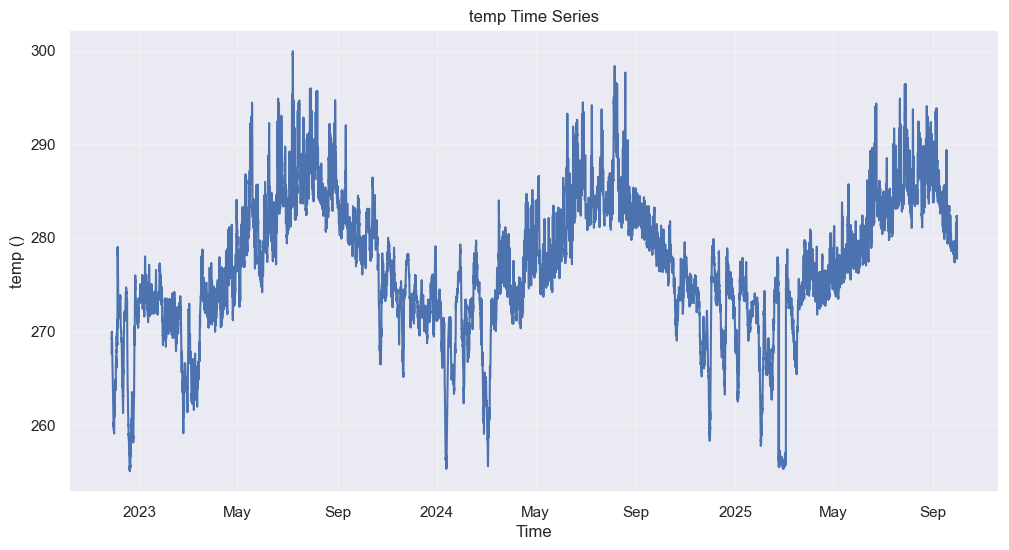

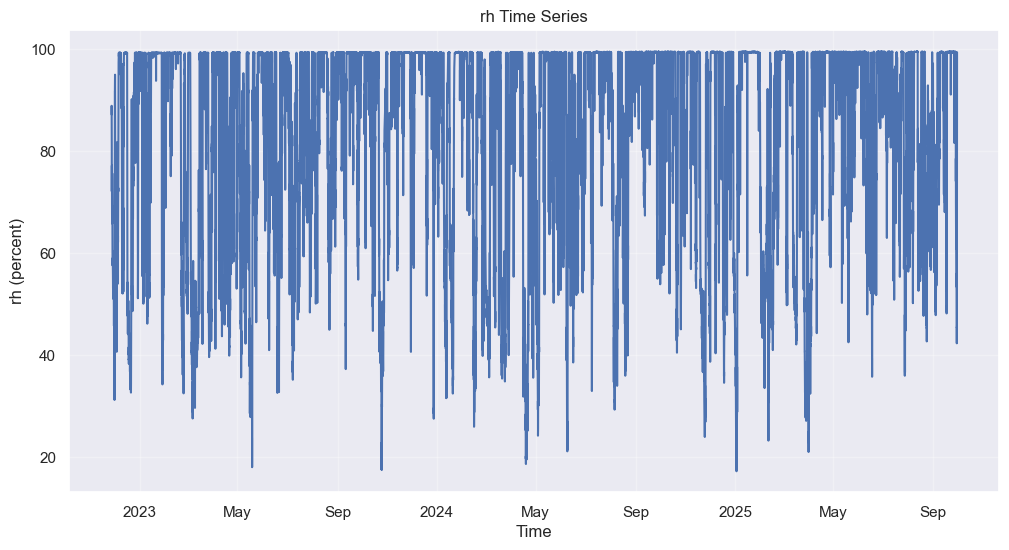

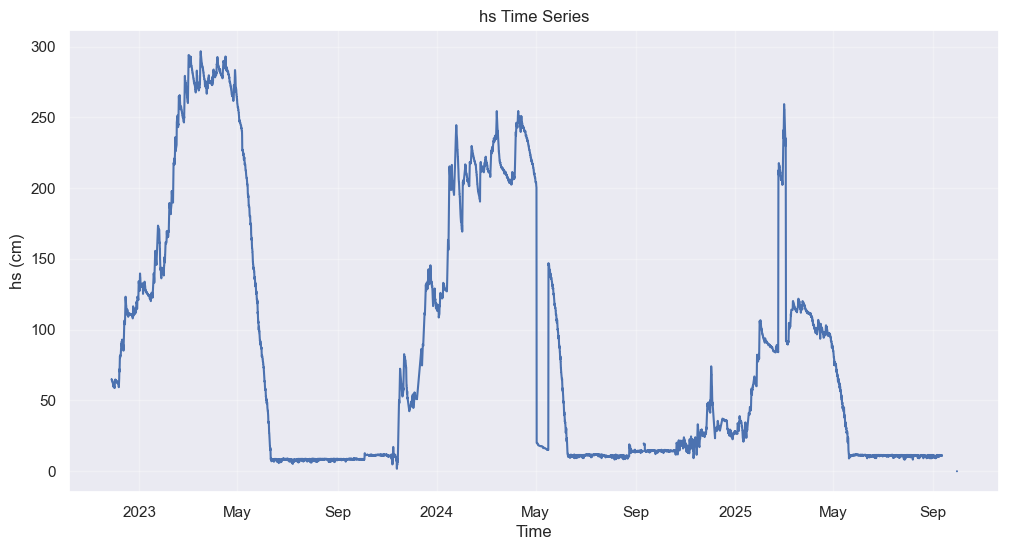

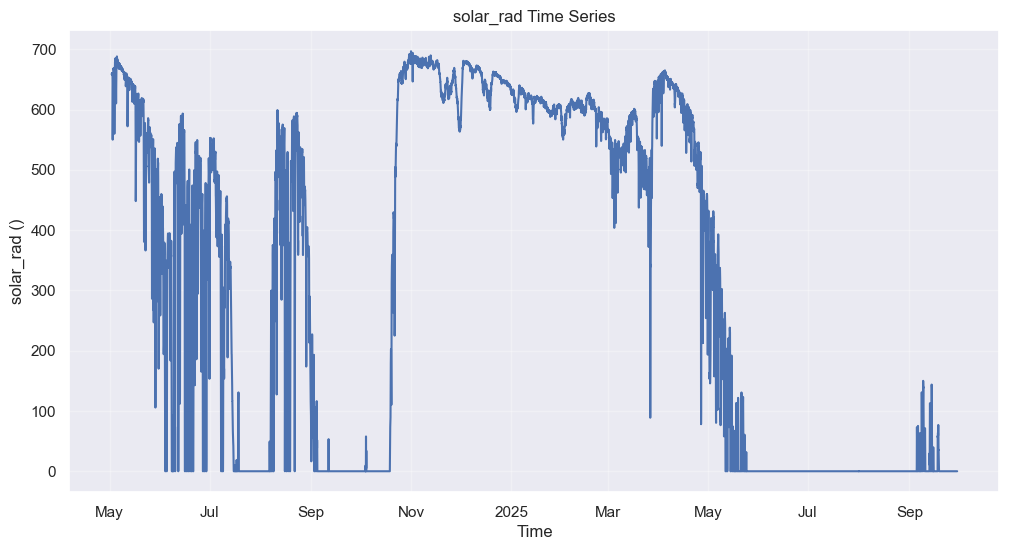

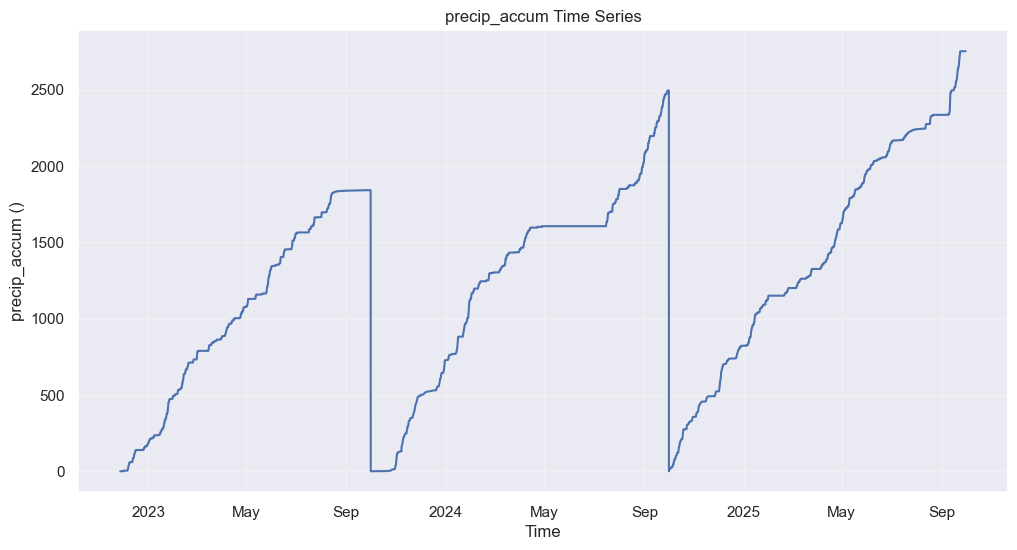

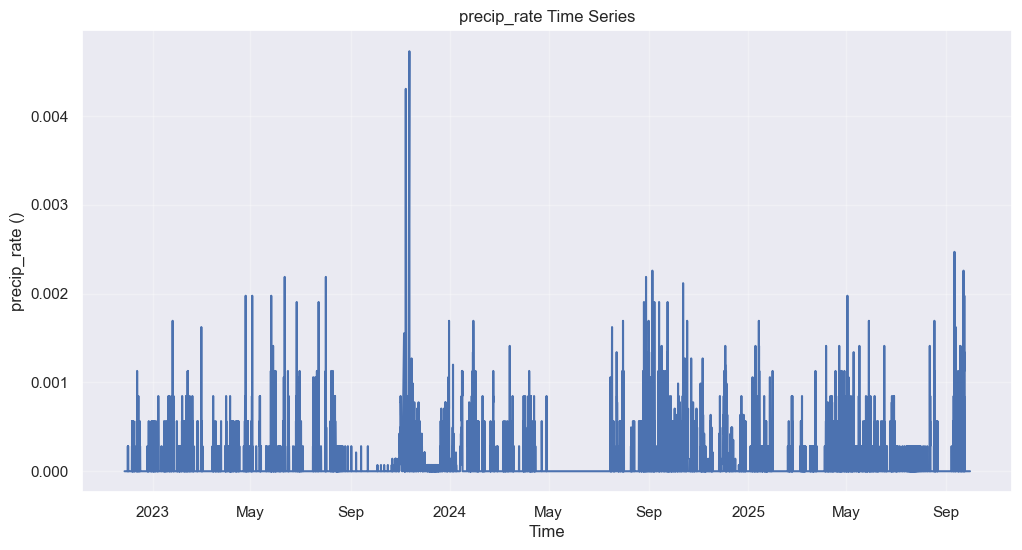

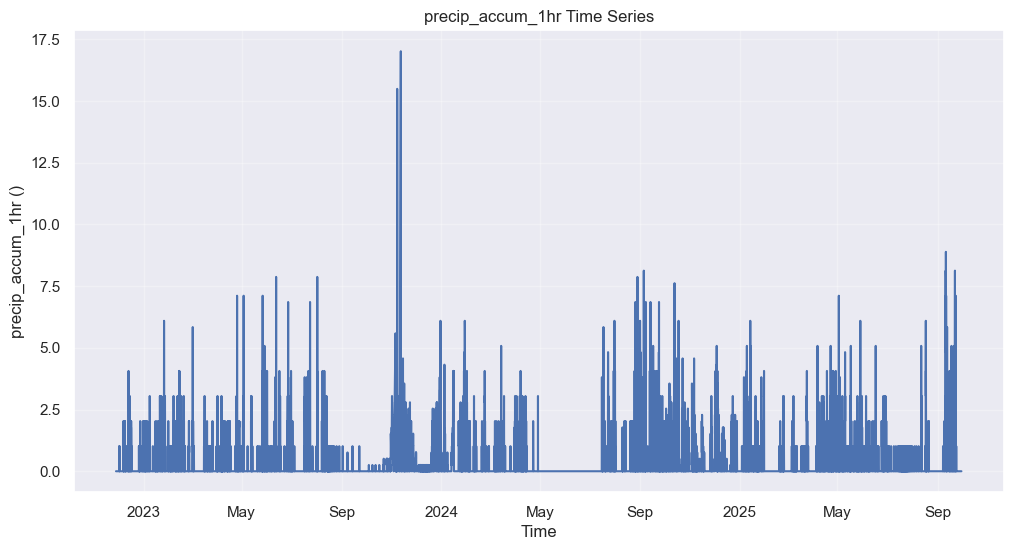

In [4]:
# plot all the variables to see what we have and how they look
for var in ds_met.data_vars:
    plt.figure()
    ds_met[var].plot()
    plt.title(f"{var} Time Series")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({ds_met[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()
    

We should not need much cleaning here since we did it largely in script 1...

_________________________________________________________________

## Load the HRRR-AK Dataset

In [5]:
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc"
ds_hrrr = xr.open_dataset(input_file)
ds_hrrr.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

# and clip to WY2020,2021,2022 
ds_hrrr = ds_hrrr.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))

ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

Compare Precipiation, 

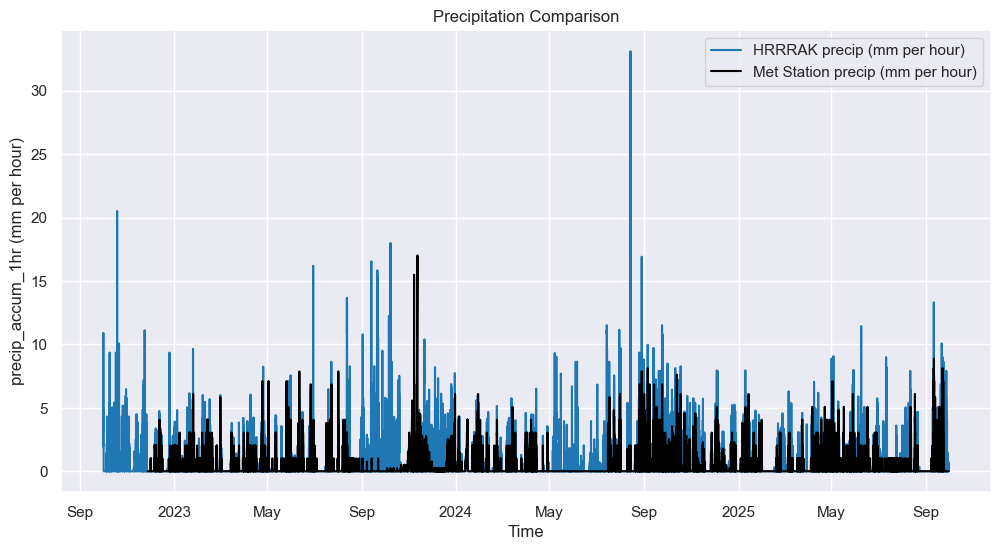

In [6]:
# compare precip 
ds_hrrr['precip_accum_1hr'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
ds_met["precip_accum_1hr"].plot(label="Met Station precip (mm per hour)", color='black')
plt.title("Precipitation Comparison")
plt.xlabel("Time")
plt.ylabel("precip_accum_1hr (mm per hour)")
plt.legend()
plt.show()

# # compare precip 
# ds_hrrr['precip_rate'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
# ds_met["precip_rate"].plot(label="Met Station precip (mm per hour)", color='black')
# plt.title("Precipitation Comparison")
# plt.xlabel("Time")
# plt.ylabel("precip_rate (mm per second)")
# plt.legend()
# plt.show()

In [7]:
# remove any precip accum that are above 20
ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_accum_1hr'].where(ds_hrrr['precip_accum_1hr'] < 20)

Compare accumulated precip, 

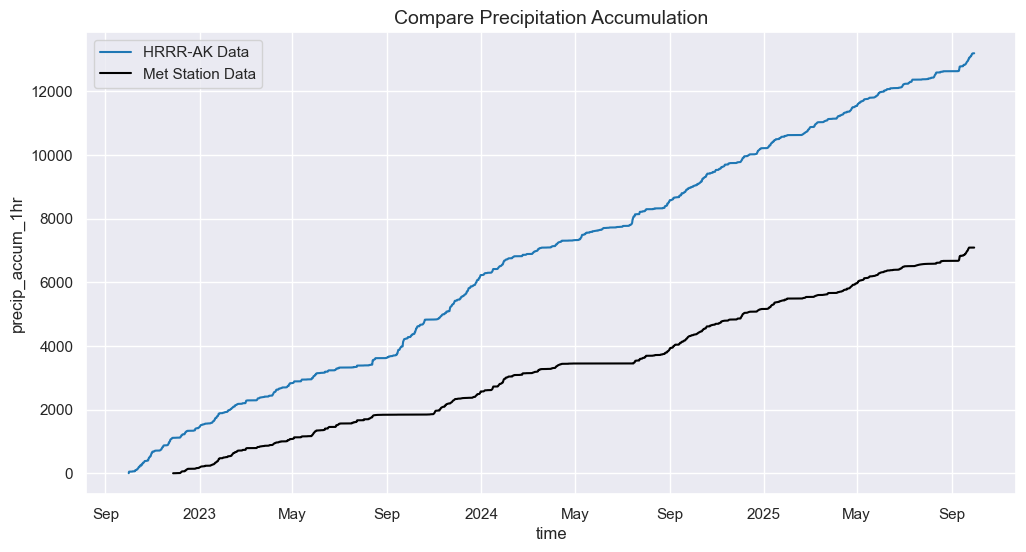

In [8]:
ds_hrrr['precip_accum_1hr'].cumsum().plot(label='HRRR-AK Data', color='tab:blue')

# now divide precip accum by 2 to compare 
# (ds_hrrr['precip_accum_1hr'].cumsum() / 1.3).plot(label='HRRR-AK Data Scale (Divide) by 1.3', color='tab:orange')
ds_met['precip_accum_1hr'].cumsum().plot(label='Met Station Data', color='black')

plt.title('Compare Precipitation Accumulation', fontsize=14)
plt.legend()
plt.show()

Air temperature, 

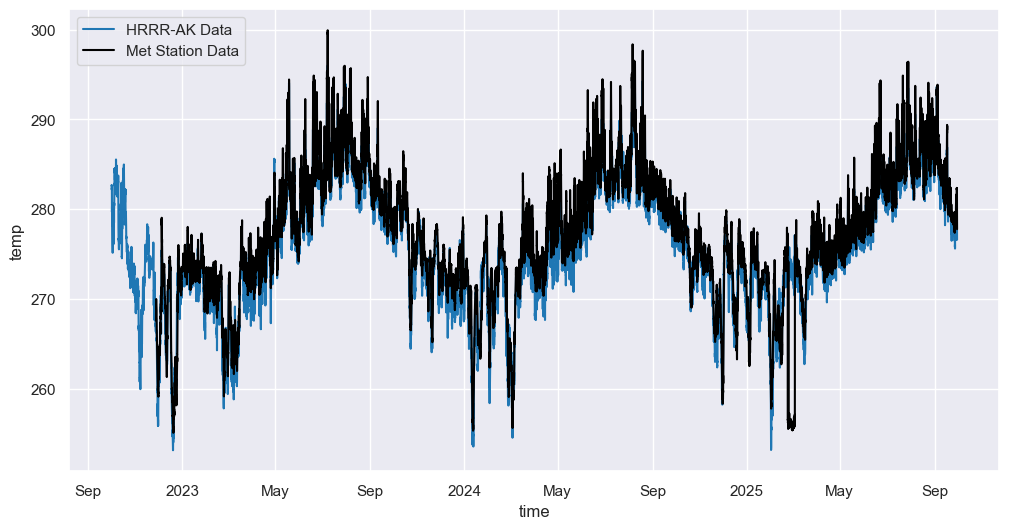

In [9]:
# compare temp
ds_hrrr.temp.plot(label='HRRR-AK Data', color='tab:blue')
ds_met.temp.plot(label='Met Station Data', color='black')
# for WY2025, there is a weird temperature drop so remove any temperatures in ds_met that are below 258
ds_met = ds_met.where(ds_met['temp'] >= 258, drop=True)
plt.legend()

There is that weird drop I do not like... so let's remove that

In [10]:
# for WY2025, there is a weird temperature drop so remove any temperatures in ds_met that are below 258
# ds_met = ds_met.where(ds_met['temp'] >= 257, drop=True)

Relative Humidity, 

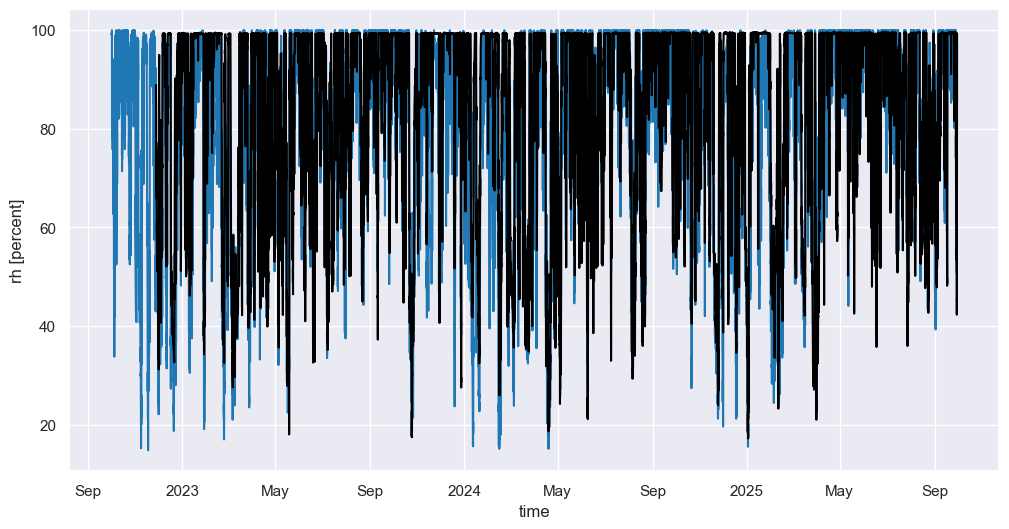

In [11]:
# compare rh 
ds_hrrr['rh'].plot(label='HRRR-AK Data', color='tab:blue')
ds_met['rh'].plot(label='Met Station Data', color='black')

### Removing the chunck of data around the model crash date,

In [ ]:
# remove a chunck of ds_met data around the crash date : 23-10-12T00:00:00

# This one did not work 
# ds_met = ds_met.where(~((ds_met['time'] >= "2023-10-11T00:00:00") & (ds_met['time'] <= "2023-10-13T00:00:00")), drop=True)

# This one worked 
ds_met = ds_met.where(~((ds_met['time'] >= np.datetime64("2023-06-11T00:00:00")) & (ds_met['time'] <= np.datetime64("2023-11-01T00:00:00"))), drop=True)

# I could try a smaller date range or only RH for example in the future if I have more time

# The Workflow Below, 

HRRR (NetCDF / xarray)\
   → your Python script\
   → SMET (ASCII)\
   → SNOWPACK


#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [13]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [14]:
from pathlib import Path
from pyproj import Transformer

In [15]:
# lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [16]:
# relate the variables, df_met is for the met station data 
ds_met = ds_met.copy()

# ds is for the HRRRAK data
ds_hrrrak = ds_hrrr.copy()

New Code, 


Original dataset ranges:
MET:  2022-11-27T16:00:00.000000000 -> 2025-09-30T05:00:00.000000000
HRRR: 2022-10-01T05:00:00.000000000 -> 2025-09-30T05:00:00.000000000



Coverage statistics:
MET precip valid fraction: 0.8001217609679997
HRRR precip valid fraction: 0.9998858490925003

Fraction of timesteps using MET data:
TA: 0.8001217609679997
RH: 0.8001217609679997
PSUM: 0.8001217609679997

Timesteps where PSUM differs from HRRR:
8699

SMET file written to:
/home/cassie/python/models/run_snowpack/sites/tram/input/met_hrrrak_WY2023-WY2025/met_hrrrak_tram_WY2023-WY2025.smet


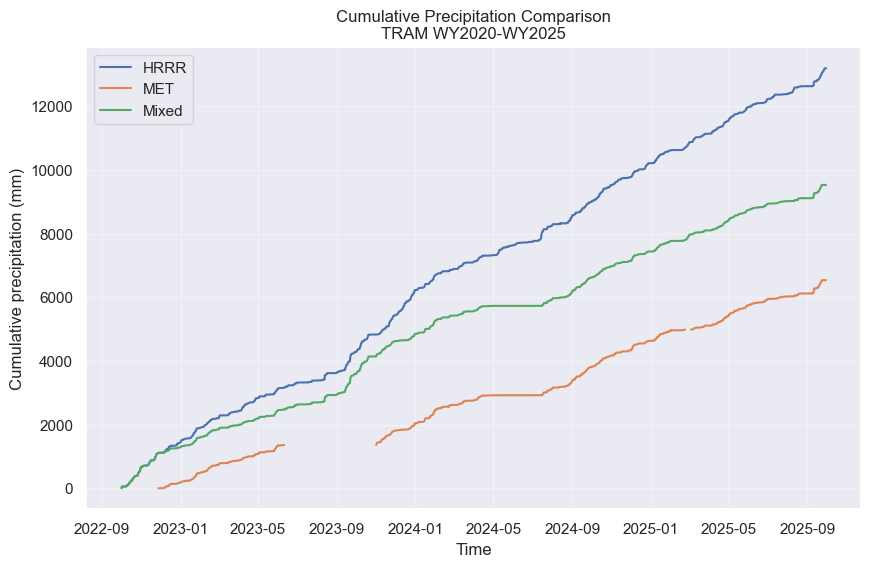

In [17]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================

start_time = '2022-10-01T05:00'
end_time   = '2025-09-30T05:00'

TIMESTEP = "1h"

OUTFILE = Path(
    "/home/cassie/python/models/run_snowpack/sites/tram/input/"
    "/met_hrrrak_WY2023-WY2025/met_hrrrak_tram_WY2023-WY2025.smet"
)

STATION_ID   = "met_hrrrak_tram_WY2023-WY2025"
STATION_NAME = "Met Station and HRRR-AK TRAM Point Forcing"

LAT  = lat_tram
LON  = lon_tram
ELEV = elevation_tram

EPSG   = 32608
TZ     = 0
NODATA = -999

# ============================================================
# SLICE TO COMMON TIME RANGE
# ============================================================

ds_met = ds_met.sel(time=slice(start_time, end_time))
ds_hrrrak = ds_hrrrak.sel(time=slice(start_time, end_time))

print("\nOriginal dataset ranges:")
print(f"MET:  {ds_met.time.min().values} -> {ds_met.time.max().values}")
print(f"HRRR: {ds_hrrrak.time.min().values} -> {ds_hrrrak.time.max().values}")

# ============================================================
# SORT TIME AXES
# ============================================================

# Always sort before resampling/reindexing
ds_met = ds_met.sortby("time")
ds_hrrrak = ds_hrrrak.sortby("time")

# ============================================================
# CREATE CONTINUOUS HOURLY TIME AXES
# ============================================================

# IMPORTANT:
# asfreq() DOES NOT average/interpolate data.
# It simply creates a regular hourly time axis and inserts NaNs
# where timestamps are missing.
#
# This is MUCH safer for precipitation accumulation variables.

ds_met = ds_met.resample(time='1h').asfreq()
ds_hrrrak = ds_hrrrak.resample(time='1h').asfreq()

# ============================================================
# ALIGN MET DATA TO HRRR TIME AXIS
# ============================================================

# Use exact HRRR timestamps as the master time axis
# and reindex MET data onto it.
#
# IMPORTANT:
# reindex() does NOT interpolate or shift storms in time.
# Missing timestamps remain NaN.

ds_met = ds_met.reindex(time=ds_hrrrak.time)

# ============================================================
# UNIT CONVERSIONS
# ============================================================

# ---- Relative Humidity ----
# Convert both datasets to fraction [0-1]

ds_met["rh"] = ds_met["rh"] / 100.0
ds_hrrrak["rh"] = ds_hrrrak["rh"] / 100.0

# ---- Temperature ----
# Ensure both are in Kelvin.
#
# Uncomment if MET temperature is in Celsius:
#
# ds_met["temp"] = ds_met["temp"] + 273.15

# ============================================================
# DIAGNOSTIC CHECKS
# ============================================================

print("\nCoverage statistics:")

print(
    "MET precip valid fraction:",
    float(ds_met["precip_accum_1hr"].notnull().mean())
)

print(
    "HRRR precip valid fraction:",
    float(ds_hrrrak["precip_accum_1hr"].notnull().mean())
)

# ============================================================
# CREATE COMBINED DATASET
# ============================================================

# combine_first() means:
#
# "Use ds_met values where available,
# otherwise fill with ds_hrrrak"
#
# EXACTLY what we want.

ds_combined = ds_met.combine_first(ds_hrrrak)

# ============================================================
# BUILD FINAL FORCING DATASET
# ============================================================

ds_filled = xr.Dataset(coords={"time": ds_hrrrak.time})

# ============================================================
# VARIABLES USING MET FIRST, THEN HRRR
# ============================================================

ds_filled["TA"] = ds_combined["temp"]
ds_filled["RH"] = ds_combined["rh"]
ds_filled["PSUM"] = ds_combined["precip_accum_1hr"]

# ============================================================
# VARIABLES ALWAYS FROM HRRR
# ============================================================

ds_filled["ISWR"] = ds_hrrrak["swrad"]
ds_filled["ILWR"] = ds_hrrrak["lwrad"]
ds_filled["PS"]   = ds_hrrrak["pressure"]

# ---- Wind speed and direction ----

u = ds_hrrrak["10u"]
v = ds_hrrrak["10v"]

ds_filled["VW"] = np.sqrt(u**2 + v**2)

# Meteorological wind direction
ds_filled["DW"] = (
    (270.0 - np.degrees(np.arctan2(v, u))) % 360.0
)

# ============================================================
# DIAGNOSTIC OUTPUT
# ============================================================

print("\nFraction of timesteps using MET data:")

print(
    "TA:",
    float(ds_met["temp"].notnull().mean())
)

print(
    "RH:",
    float(ds_met["rh"].notnull().mean())
)

print(
    "PSUM:",
    float(ds_met["precip_accum_1hr"].notnull().mean())
)

print("\nTimesteps where PSUM differs from HRRR:")

print(
    int(
        (ds_filled["PSUM"] != ds_hrrrak["precip_accum_1hr"]).sum()
    )
)

# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

df_smet = ds_filled.to_dataframe()

# ============================================================
# FINAL TIME HANDLING
# ============================================================

# Since data are ALREADY hourly,
# we avoid another resample().sum()/mean().
#
# This prevents accidental precipitation corruption.

df_smet = df_smet.asfreq(TIMESTEP)

# ============================================================
# REPLACE MISSING VALUES
# ============================================================

df_smet = df_smet.fillna(NODATA)

# ============================================================
# COORDINATE TRANSFORM
# ============================================================

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32608",
    always_xy=True
)

EASTING, NORTHING = transformer.transform(LON, LAT)

# ============================================================
# WRITE SMET FILE
# ============================================================

with open(OUTFILE, "w") as f:

    f.write("SMET 1.1 ASCII\n")

    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = MET filled with HRRR-AK\n")

    f.write(
        "fields           = "
        "timestamp TA RH VW DW ISWR ILWR PSUM PS\n"
    )

    f.write("[DATA]\n")

    for t, row in df_smet.iterrows():

        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} "
            f"{row.RH:6.3f} "
            f"{row.VW:6.2f} "
            f"{row.DW:6.1f} "
            f"{row.ISWR:8.1f} "
            f"{row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} "
            f"{row.PS:8.1f}\n"
        )

print(f"\nSMET file written to:\n{OUTFILE}")

# ============================================================
# PRECIPITATION COMPARISON PLOT
# ============================================================

plt.figure(figsize=(10, 6))

# HRRR precip
plt.plot(
    ds_hrrrak["precip_accum_1hr"].to_series().cumsum(),
    label="HRRR",
)

# MET precip
plt.plot(
    ds_met["precip_accum_1hr"].to_series().cumsum(),
    label="MET",
)

# Mixed precip
plt.plot(
    ds_filled["PSUM"].to_series().cumsum(),
    label="Mixed",
)

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")

plt.title(
    "Cumulative Precipitation Comparison\n"
    "TRAM WY2020-WY2025"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Create .SNO File 

In [18]:
# ============================================================
# CREATE EMPTY .SNO FILE
# ============================================================

# This creates an EMPTY snow profile initialization file
# for SNOWPACK.
#
# The file contains:
# - site metadata matching the SMET forcing file
# - an empty snowpack (nSnowLayerData = 0)
# - an initialization date matching the forcing start time
#
# IMPORTANT:
# SNOWPACK typically initializes the snowpack ONE TIMESTEP
# BEFORE forcing begins.
#
# Here we use:
# ProfileDate = start_time + 1 day
#
# This block is intentionally reusable for future sites.

from datetime import timedelta

# ============================================================
# OUTPUT FILE
# ============================================================

OUTFILE_SNO = Path(
    "/home/cassie/python/models/run_snowpack/sites/tram/input/"
    "/met_hrrrak_WY2023-WY2025/met_hrrrak_tram_WY2023-WY2025.sno"
)

# ============================================================
# PROFILE DATE
# ============================================================

# Convert start time to pandas datetime
profile_date = pd.to_datetime(start_time) + timedelta(days=1)

# Format for SNOWPACK
profile_date_str = profile_date.strftime("%Y-%m-%dT%H:%M")

# ============================================================
# OPTIONAL SITE PARAMETERS
# ============================================================

# These can later be customized per site

SLOPE_ANGLE = 38.0
SLOPE_AZI   = 0.0

SOIL_ALBEDO = 0.09
BARE_SOIL_Z0 = 0.200

CANOPY_HEIGHT = 0.00
CANOPY_LAI = 0.00
CANOPY_DIRECT_THROUGHFALL = 1.00

WIND_SCALING_FACTOR = 1.00

# ============================================================
# WRITE SNO FILE
# ============================================================

with open(OUTFILE_SNO, "w") as f:

    f.write("SMET 1.1 ASCII\n")

    f.write("[HEADER]\n")

    # --------------------------------------------------------
    # SITE INFORMATION
    # --------------------------------------------------------

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")

    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = MET filled with HRRR-AK\n")

    # --------------------------------------------------------
    # SNOWPACK INITIALIZATION SETTINGS
    # --------------------------------------------------------

    f.write(f"ProfileDate      = {profile_date_str}\n")

    # Initial snow height
    f.write("HS_Last          = 0.0000\n")

    # Terrain
    f.write(f"SlopeAngle       = {SLOPE_ANGLE:.1f}\n")
    f.write(f"SlopeAzi         = {SLOPE_AZI:.1f}\n")

    # Empty snowpack / soil profile
    f.write("nSoilLayerData   = 0\n")
    f.write("nSnowLayerData   = 0\n")

    # Soil / canopy parameters
    f.write(f"SoilAlbedo       = {SOIL_ALBEDO:.2f}\n")
    f.write(f"BareSoil_z0      = {BARE_SOIL_Z0:.3f}\n")

    f.write(f"CanopyHeight     = {CANOPY_HEIGHT:.2f}\n")
    f.write(f"CanopyLeafAreaIndex = {CANOPY_LAI:.2f}\n")

    f.write(
        f"CanopyDirectThroughfall = "
        f"{CANOPY_DIRECT_THROUGHFALL:.2f}\n"
    )

    f.write(
        f"WindScalingFactor = "
        f"{WIND_SCALING_FACTOR:.2f}\n"
    )

    f.write("ErosionLevel     = 0\n")

    f.write("TimeCountDeltaHS = 0.000000\n")

    # --------------------------------------------------------
    # REQUIRED FIELD DEFINITIONS
    # --------------------------------------------------------

    f.write(
        "fields           = "
        "timestamp Layer_Thick T Vol_Frac_I "
        "Vol_Frac_W Vol_Frac_V Vol_Frac_S "
        "Rho_S Conduc_S HeatCapac_S "
        "rg rb dd sp mk mass_hoar ne CDot metamo\n"
    )

    # --------------------------------------------------------
    # EMPTY DATA SECTION
    # --------------------------------------------------------

    f.write("[DATA]\n")

print(f"\nSNO file written to:\n{OUTFILE_SNO}")


SNO file written to:
/home/cassie/python/models/run_snowpack/sites/tram/input/met_hrrrak_WY2023-WY2025/met_hrrrak_tram_WY2023-WY2025.sno


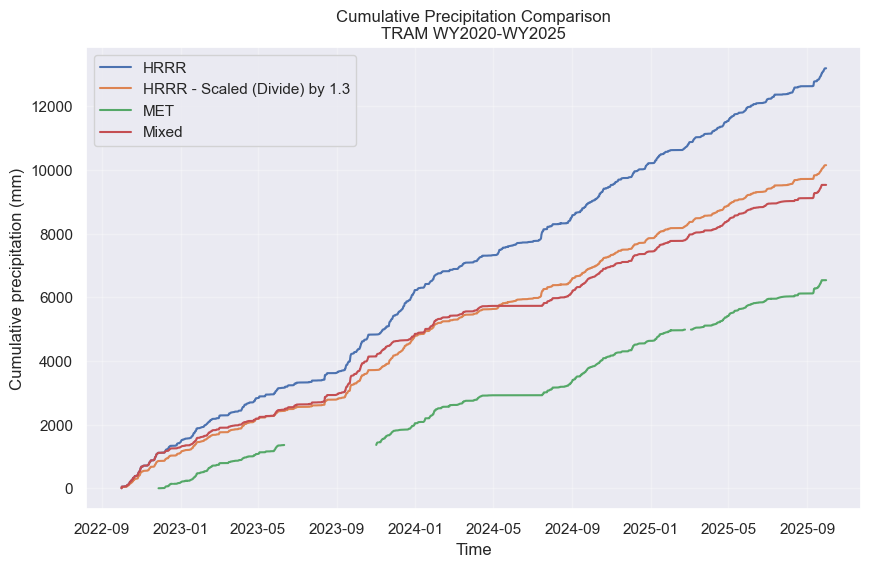

In [19]:
# ============================================================
# PRECIPITATION COMPARISON PLOT
# ============================================================

plt.figure(figsize=(10, 6))

# HRRR precip
plt.plot(
    ds_hrrrak["precip_accum_1hr"].to_series().cumsum(),
    label="HRRR",
)

# HRRR precip
plt.plot(
    ds_hrrrak["precip_accum_1hr"].to_series().cumsum()/1.3,
    label="HRRR - Scaled (Divide) by 1.3",
)

# MET precip
plt.plot(
    ds_met["precip_accum_1hr"].to_series().cumsum(),
    label="MET",
)

# Mixed precip
plt.plot(
    ds_filled["PSUM"].to_series().cumsum(),
    label="Mixed",
)

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")

plt.title(
    "Cumulative Precipitation Comparison\n"
    "TRAM WY2020-WY2025"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

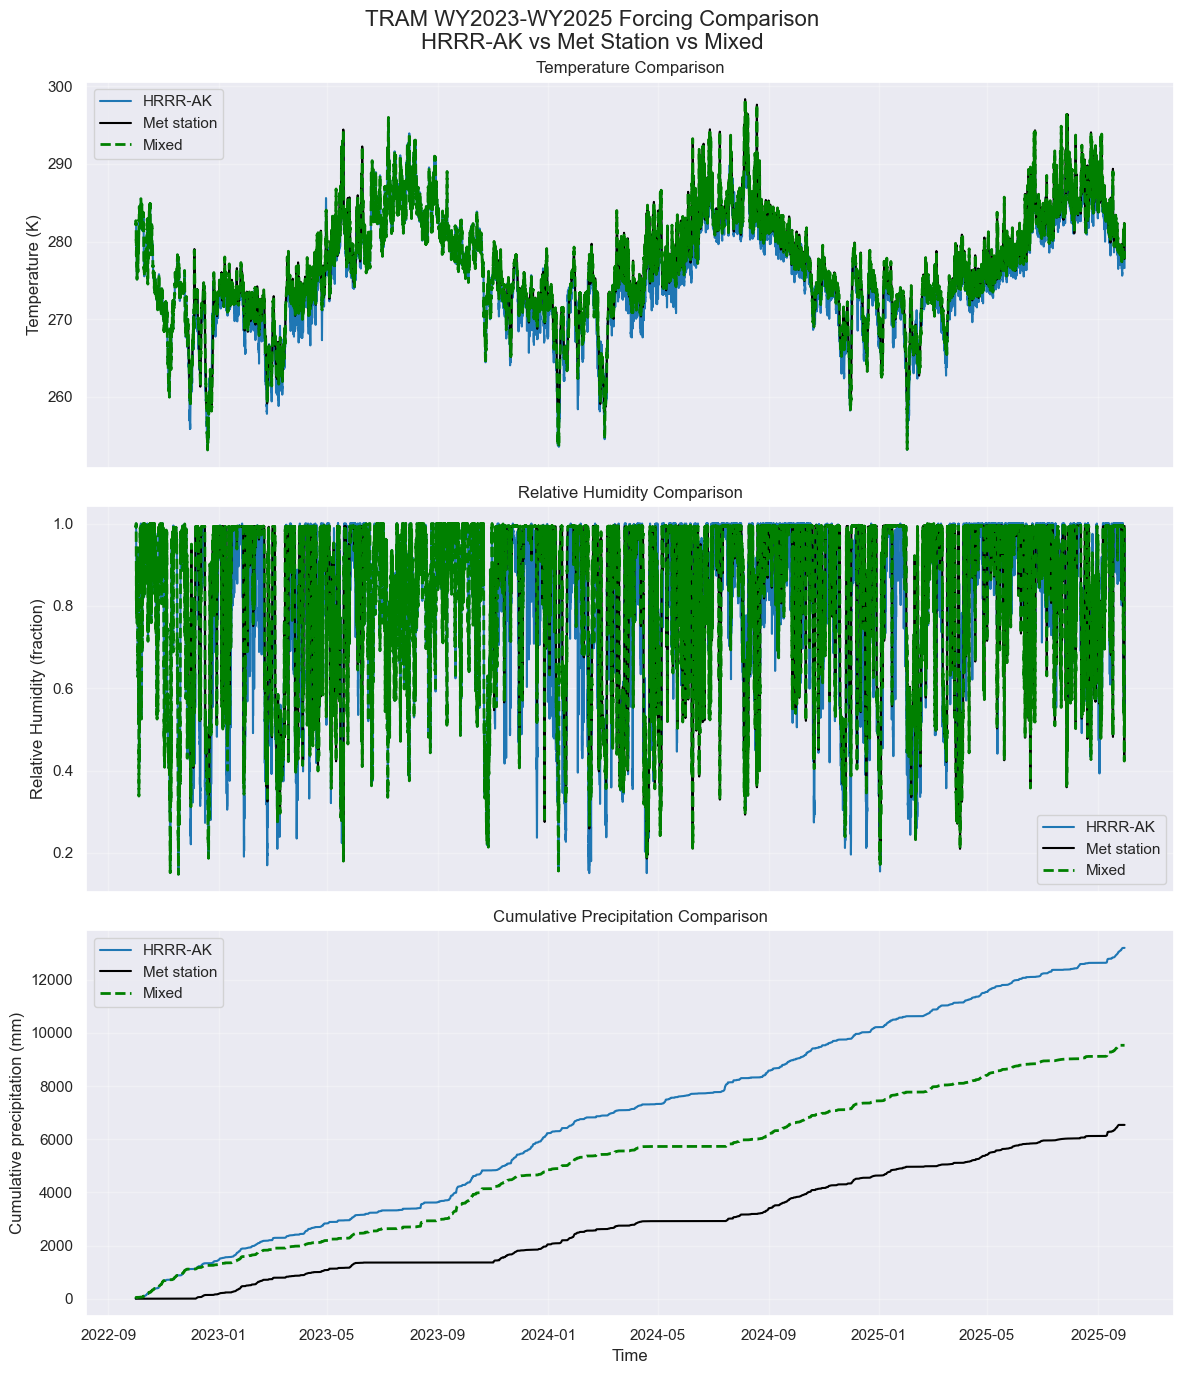

In [21]:
# ============================================================
# MULTI-VARIABLE COMPARISON PLOT
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14),
    sharex=True
)

# ============================================================
# TEMPERATURE
# ============================================================

ax = axes[0]

# All datasets already aligned and in Kelvin

ax.plot(
    ds_hrrrak["temp"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_met["temp"].to_series(),
    label="Met station",
    color="black"
)

ax.plot(
    ds_filled["TA"].to_series(),
    label="Mixed",
    color="green",
    linestyle="--",
    linewidth=2
)

ax.set_ylabel("Temperature (K)")
ax.set_title("Temperature Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# RELATIVE HUMIDITY
# ============================================================

ax = axes[1]

# RH already converted to fraction [0-1]

ax.plot(
    ds_hrrrak["rh"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_met["rh"].to_series(),
    label="Met station",
    color="black"
)

ax.plot(
    ds_filled["RH"].to_series(),
    label="Mixed",
    color="green",
    linestyle="--",
    linewidth=2
)

ax.set_ylabel("Relative Humidity (fraction)")
ax.set_title("Relative Humidity Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# PRECIPITATION
# ============================================================

ax = axes[2]

# Plot cumulative precipitation
# Skip NaNs before cumsum to avoid propagation

ax.plot(
    ds_hrrrak["precip_accum_1hr"]
    .fillna(0)
    .to_series()
    .cumsum(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_met["precip_accum_1hr"]
    .fillna(0)
    .to_series()
    .cumsum(),
    label="Met station",
    color="black"
)

ax.plot(
    ds_filled["PSUM"]
    .fillna(0)
    .to_series()
    .cumsum(),
    label="Mixed",
    color="green",
    linestyle="--",
    linewidth=2
)

ax.set_ylabel("Cumulative precipitation (mm)")
ax.set_title("Cumulative Precipitation Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# COMMON X-AXIS
# ============================================================

axes[-1].set_xlabel("Time")

plt.suptitle(
    "TRAM WY2023-WY2025 Forcing Comparison\n"
    "HRRR-AK vs Met Station vs Mixed",
    fontsize=16
)

plt.tight_layout()

plt.show()